In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    recall_score, f1_score,
    balanced_accuracy_score,
    confusion_matrix
)



In [ ]:
train_df = pd.read_csv("features_train.csv")
test_df  = pd.read_csv("features_test.csv")

files= test_df["person"].values
X_train = train_df.drop(columns=["label", "person"])
y_train = train_df["label"].values

X_test = test_df.drop(columns=["label", "person"])
y_test = test_df["label"].values



NameError: name 'pd' is not defined

NORMALISATION MinMaxScaler (0-1) - FIT sur TRAIN
TRAIN brut: (86, 18) | TEST brut: (37, 18)

APRÈS normalisation:
  TRAIN min=0.0000, max=1.0000
  TEST  min=0.0000, max=1.4815


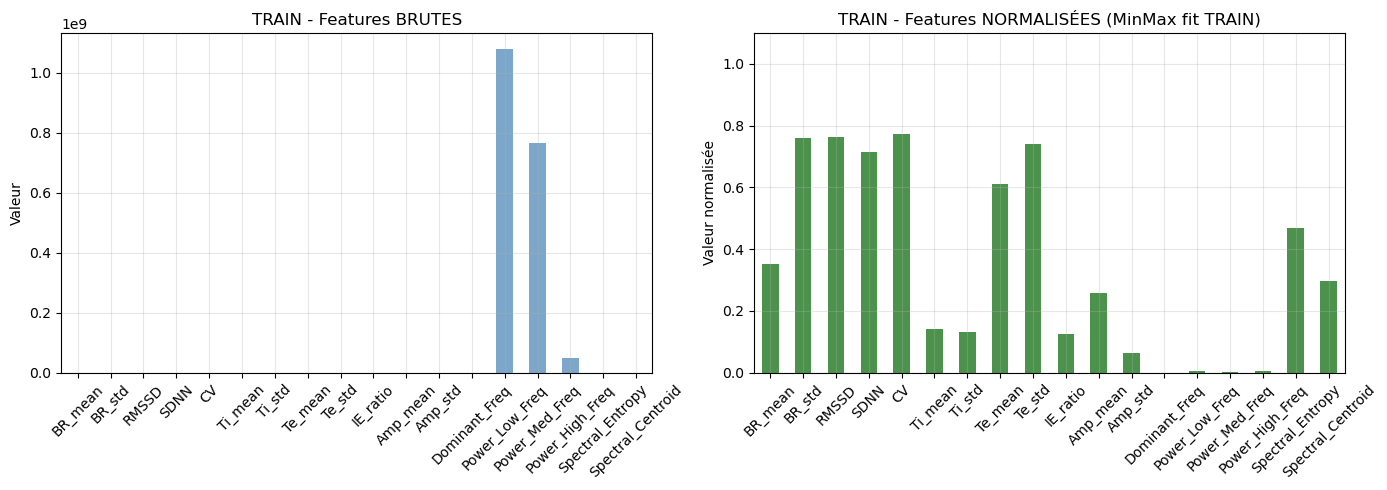


✓ Normalisation standard complétée


In [3]:
# Normalisation "standard" (recommandée) : fit sur TRAIN, transform sur TRAIN + TEST
# Objectif: éviter toute fuite d'information du TEST dans le pré-traitement.

from sklearn.preprocessing import MinMaxScaler

# Garder person (utile si tu veux plus tard une CV par personne)
train_person = train_df['person'].copy()
test_person = test_df['person'].copy()

# Séparer features et labels (TRAIN)
X_train_raw = train_df.drop(['label', 'person'], axis=1)
y_train = train_df['label']

# Séparer features et labels (TEST)
X_test_raw = test_df.drop(['label', 'person'], axis=1)
y_test = test_df['label']

assert list(X_train_raw.columns) == list(X_test_raw.columns), "Colonnes train/test différentes !"

print("=" * 60)
print("NORMALISATION MinMaxScaler (0-1) - FIT sur TRAIN")
print("=" * 60)
print(f"TRAIN brut: {X_train_raw.shape} | TEST brut: {X_test_raw.shape}")

scaler = MinMaxScaler(feature_range=(0, 1))
X_train = pd.DataFrame(
    scaler.fit_transform(X_train_raw),
    columns=X_train_raw.columns,
    index=X_train_raw.index
 )
X_test = pd.DataFrame(
    scaler.transform(X_test_raw),
    columns=X_test_raw.columns,
    index=X_test_raw.index
 )

print("\nAPRÈS normalisation:")
print(f"  TRAIN min={X_train.min().min():.4f}, max={X_train.max().max():.4f}")
print(f"  TEST  min={X_test.min().min():.4f}, max={X_test.max().max():.4f}")

# Visualisation: une session TRAIN avant/après
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
X_train_raw.iloc[0].plot(kind='bar', ax=axes[0], color='steelblue', alpha=0.7)
axes[0].set_title('TRAIN - Features BRUTES')
axes[0].set_ylabel('Valeur')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3)

X_train.iloc[0].plot(kind='bar', ax=axes[1], color='darkgreen', alpha=0.7)
axes[1].set_title('TRAIN - Features NORMALISÉES (MinMax fit TRAIN)')
axes[1].set_ylabel('Valeur normalisée')
axes[1].set_ylim([0, 1.1])
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Normalisation standard complétée")

TRAIN/TEST (SANS SPLIT)

DATA TRAIN:
  X_train shape: (86, 18)
  y_train shape: (86,)
  Distribution: Sain=55, Diabétique=31

DATA TEST:
  X_test shape: (37, 18)
  y_test shape: (37,)
  Distribution: Sain=24, Diabétique=13


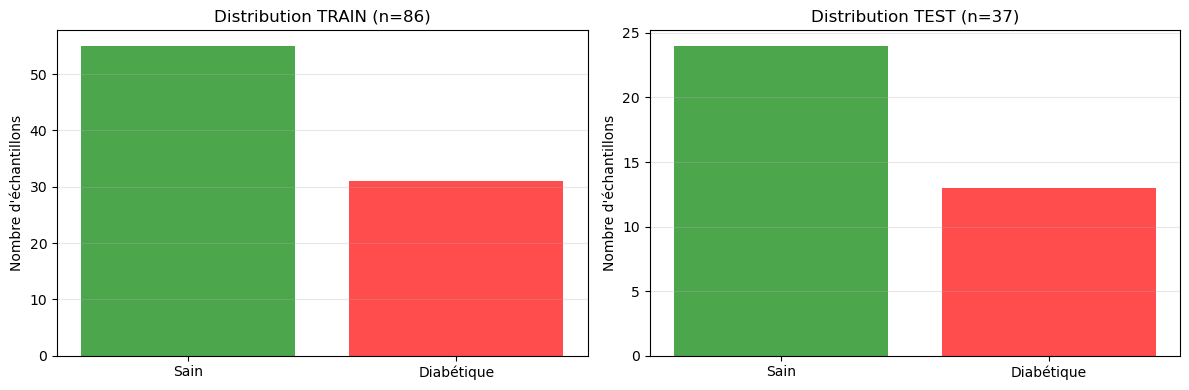


✓ Train/Test prêts (sans split)


In [4]:
print("=" * 60)
print("TRAIN/TEST (SANS SPLIT)")
print("=" * 60)

print(f"\nDATA TRAIN:")
print(f"  X_train shape: {X_train.shape}")
print(f"  y_train shape: {y_train.shape}")
print(f"  Distribution: Sain={sum(y_train==0)}, Diabétique={sum(y_train==1)}")

print(f"\nDATA TEST:")
print(f"  X_test shape: {X_test.shape}")
print(f"  y_test shape: {y_test.shape}")
print(f"  Distribution: Sain={sum(y_test==0)}, Diabétique={sum(y_test==1)}")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

train_counts = y_train.value_counts()
test_counts = y_test.value_counts()

axes[0].bar(['Sain', 'Diabétique'], [train_counts.get(0, 0), train_counts.get(1, 0)], color=['green', 'red'], alpha=0.7)
axes[0].set_title(f'Distribution TRAIN (n={len(y_train)})')
axes[0].set_ylabel('Nombre d\'échantillons')
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].bar(['Sain', 'Diabétique'], [test_counts.get(0, 0), test_counts.get(1, 0)], color=['green', 'red'], alpha=0.7)
axes[1].set_title(f'Distribution TEST (n={len(y_test)})')
axes[1].set_ylabel('Nombre d\'échantillons')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n✓ Train/Test prêts (sans split)")

In [5]:
print("=" * 60)
print("ENTRAÎNEMENT DES MODÈLES (candidats + pondération par personne)")
print("=" * 60)

from sklearn.ensemble import (
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    HistGradientBoostingClassifier,
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.utils.class_weight import compute_sample_weight

# Dictionnaire pour stocker les modèles
models = {}

# --- Pondération: éviter qu'une personne avec beaucoup de sessions domine ---
# (utile quand plusieurs sessions par personne)
train_person = train_person.reindex(y_train.index)

# Poids de classe (minorité => + lourd)
sample_w_class = compute_sample_weight(class_weight="balanced", y=y_train)

# Poids par personne: somme ~1 par personne (réduit l'effet "personnes très enregistrées")
per_person_counts = train_person.value_counts()
sample_w_person = train_person.map(lambda p: 1.0 / float(per_person_counts.loc[p])).values

# Combinaison (pour les modèles utilisant sample_weight)
sample_w = sample_w_class * sample_w_person
# Renormaliser pour garder une échelle stable
sample_w = sample_w / float(np.mean(sample_w))

print(f"Pondération: n_personnes_train={train_person.nunique()} | mean_w={sample_w.mean():.3f}")



# 2) Random Forest
print("2️⃣ Random Forest (class_weight=balanced_subsample + sample_weight par personne)...")
rf_model = RandomForestClassifier(
    n_estimators=1000,
    random_state=42,
    class_weight="balanced_subsample",
    min_samples_leaf=2,
    n_jobs=-1,
)
rf_model.fit(X_train, y_train, sample_weight=sample_w_person)
models["Random Forest"] = rf_model
print(f"   ✓ Entraîné sur shape: {X_train.shape}")





ENTRAÎNEMENT DES MODÈLES (candidats + pondération par personne)
Pondération: n_personnes_train=19 | mean_w=1.000
2️⃣ Random Forest (class_weight=balanced_subsample + sample_weight par personne)...
   ✓ Entraîné sur shape: (86, 18)


In [6]:
# ===================== LOOCV: choix du seuil (SANS TOP-4) =====================
# Ici on calcule un seuil par modèle sur TRAIN via Leave-One-Out CV,
# mais on NE filtre PAS les modèles: on garde tous les modèles candidats.

from sklearn.model_selection import LeaveOneOut
from sklearn.base import clone
from sklearn.metrics import balanced_accuracy_score, f1_score


def get_positive_proba(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, "decision_function"):
        s = model.decision_function(X)
        return 1 / (1 + np.exp(-s))
    raise ValueError("Pas de score/proba disponible")


def make_cv_estimator(fitted_model):
    """Clone le modèle et réduit un peu les hyperparams coûteux pour rendre LOOCV faisable."""
    est = clone(fitted_model)

    try:
        if hasattr(est, "n_estimators"):
            est.set_params(n_estimators=min(int(getattr(est, "n_estimators")), 200))
    except Exception:
        pass

    try:
        if hasattr(est, "max_iter"):
            est.set_params(max_iter=min(int(getattr(est, "max_iter")), 200))
    except Exception:
        pass

    try:
        if hasattr(est, "n_jobs"):
            est.set_params(n_jobs=-1)
    except Exception:
        pass

    return est


def oof_positive_proba_loocv(fitted_model, X, y, sample_weight=None):
    loo = LeaveOneOut()
    oof = np.zeros(len(y), dtype=float)

    for train_idx, test_idx in loo.split(X, y):
        est = make_cv_estimator(fitted_model)

        X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
        X_te = X.iloc[test_idx]

        if sample_weight is not None:
            sw_tr = np.asarray(sample_weight)[train_idx]
            try:
                est.fit(X_tr, y_tr, sample_weight=sw_tr)
            except TypeError:
                est.fit(X_tr, y_tr)
        else:
            est.fit(X_tr, y_tr)

        oof[test_idx[0]] = float(get_positive_proba(est, X_te)[0])

    return oof


def best_threshold_balanced(proba, y):
    thresholds = np.linspace(0.05, 0.95, 91)
    best = {
        "thr": 0.5,
        "bal_acc": -1.0,
        "f1_macro": -1.0,
        "recall_diab": -1.0,
        "specificity_sain": -1.0,
    }

    y = np.asarray(y)

    for t in thresholds:
        y_hat = (proba >= t).astype(int)

        bal_acc = balanced_accuracy_score(y, y_hat)
        f1_macro = f1_score(y, y_hat, average="macro", zero_division=0)

        tp = int(((y == 1) & (y_hat == 1)).sum())
        fn = int(((y == 1) & (y_hat == 0)).sum())
        recall_diab = tp / (tp + fn) if (tp + fn) else 0.0

        tn = int(((y == 0) & (y_hat == 0)).sum())
        fp = int(((y == 0) & (y_hat == 1)).sum())
        specificity = tn / (tn + fp) if (tn + fp) else 0.0

        # Critère principal: balanced accuracy (bon pour les 2 classes)
        # Tie-breaker: f1_macro, puis seuil plus proche de 0.5
        if (
            (bal_acc > best["bal_acc"])
            or (bal_acc == best["bal_acc"] and f1_macro > best["f1_macro"])
            or (
                bal_acc == best["bal_acc"]
                and f1_macro == best["f1_macro"]
                and abs(t - 0.5) < abs(best["thr"] - 0.5)
            )
        ):
            best = {
                "thr": float(t),
                "bal_acc": float(bal_acc),
                "f1_macro": float(f1_macro),
                "recall_diab": float(recall_diab),
                "specificity_sain": float(specificity),
            }

    return best


# sample_w existe si tu as exécuté la cellule d'entraînement; sinon on le calcule ici
try:
    _ = sample_w
except NameError:
    from sklearn.utils.class_weight import compute_sample_weight

    sample_w = compute_sample_weight(class_weight="balanced", y=y_train)

print("=" * 60)
print("LOOCV: seuil optimal (Balanced Accuracy) — SANS TOP-4")
print("=" * 60)

thresholds_by_model = {}
cv_rows = []

for name, fitted_model in models.items():
    try:
        print(f"\n→ LOOCV sur: {name}")
        proba_oof = oof_positive_proba_loocv(fitted_model, X_train, y_train, sample_weight=sample_w)
        best = best_threshold_balanced(proba_oof, y_train.values)

        thresholds_by_model[name] = best
        cv_rows.append({"Model": name, **best})

        print(
            f"{name:>22} | thr={best['thr']:.2f} | bal_acc={best['bal_acc']:.3f} | f1_macro={best['f1_macro']:.3f} | "
            f"recall(diabet)={best['recall_diab']:.3f} | specificity(sain)={best['specificity_sain']:.3f}"
        )

    except Exception as e:
        thresholds_by_model[name] = {
            "thr": 0.5,
            "bal_acc": -1.0,
            "f1_macro": -1.0,
            "recall_diab": -1.0,
            "specificity_sain": -1.0,
        }
        cv_rows.append({"Model": name, **thresholds_by_model[name]})
        print(f"{name:>22} | seuil=0.50 (fallback) | raison: {e}")

cv_df = pd.DataFrame(cv_rows).sort_values(["bal_acc", "f1_macro"], ascending=False)
print("\n" + "=" * 60)
print("RÉSULTATS LOOCV (triés)")
print("=" * 60)
display(cv_df)

print("\n✓ LOOCV seuils terminés (aucun modèle supprimé)")


LOOCV: seuil optimal (Balanced Accuracy) — SANS TOP-4

→ LOOCV sur: Random Forest
         Random Forest | thr=0.36 | bal_acc=0.783 | f1_macro=0.761 | recall(diabet)=0.839 | specificity(sain)=0.727

RÉSULTATS LOOCV (triés)


,Model,thr,bal_acc,f1_macro,recall_diab,specificity_sain
0,Random Forest,0.36,0.782991,0.761111,0.83871,0.727273



✓ LOOCV seuils terminés (aucun modèle supprimé)


In [7]:
# ===================== ÉVALUATION (focus détection diabétique) =====================
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, fbeta_score, balanced_accuracy_score
  )

def eval_with_threshold(y_true, proba, thr):
    y_pred = (proba >= thr).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) else 0.0
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'f2': fbeta_score(y_true, y_pred, beta=2.0, zero_division=0),
        'specificity': specificity,
        'confusion_matrix': cm,
        'y_pred': y_pred
    }

print("=" * 60)
print("ÉVALUATION SUR TEST SET")
print("=" * 60)
print(f"Test set shape: X_test={X_test.shape}, y_test={y_test.shape}")

results = {}

for model_name, model in models.items():
    # Probas/score
    if hasattr(model, 'predict_proba'):
        proba_test = model.predict_proba(X_test)[:, 1]
    else:
        s = model.decision_function(X_test)
        proba_test = 1 / (1 + np.exp(-s))

    thr = thresholds_by_model.get(model_name, {}).get('thr', 0.5)
    m = eval_with_threshold(y_test.values, proba_test, thr)
    results[model_name] = m

    print(f"\n{'='*60}")
    print(f"📊 {model_name.upper()} | seuil={thr:.2f}")
    print(f"{'='*60}")
    print(f"Accuracy:          {m['accuracy']:.4f}")
    print(f"Balanced Accuracy: {m['balanced_accuracy']:.4f}")
    print(f"Precision (diab):  {m['precision']:.4f}")
    print(f"Recall (diab):     {m['recall']:.4f}  ← sensibilité")
    print(f"Specificity (sain):{m['specificity']:.4f}")
    print(f"F1:                {m['f1']:.4f}")
    print(f"F2 (focus recall): {m['f2']:.4f}")

    cm = m['confusion_matrix']
    print(f"\nConfusion Matrix:")
    print(f"                Prédits")
    print(f"                Sain    Diabétique")
    print(f"Réels Sain      {cm[0,0]:<7} {cm[0,1]}")
    print(f"      Diabétique {cm[1,0]:<7} {cm[1,1]}")

    print("\nClassification Report:")
    print(classification_report(y_test, m['y_pred'], target_names=['Sain', 'Diabétique'], zero_division=0))

print("\n✓ Évaluation complétée")

ÉVALUATION SUR TEST SET
Test set shape: X_test=(37, 18), y_test=(37,)

📊 RANDOM FOREST | seuil=0.36
Accuracy:          0.8649
Balanced Accuracy: 0.8077
Precision (diab):  1.0000
Recall (diab):     0.6154  ← sensibilité
Specificity (sain):1.0000
F1:                0.7619
F2 (focus recall): 0.6667

Confusion Matrix:
                Prédits
                Sain    Diabétique
Réels Sain      24      0
      Diabétique 5       8

Classification Report:
              precision    recall  f1-score   support

        Sain       0.83      1.00      0.91        24
  Diabétique       1.00      0.62      0.76        13

    accuracy                           0.86        37
   macro avg       0.91      0.81      0.83        37
weighted avg       0.89      0.86      0.86        37


✓ Évaluation complétée
